# BESS-Optimierung am Day-Ahead-Markt mit PyPSA

<div style="
    background:rgba(255,255,255,0.055);
    border:1px solid rgba(255,255,255,0.14);
    border-left:4px solid rgba(160,160,160,0.55);
    border-radius:8px;
    padding:10px 14px;
    margin:10px 0 14px 0;
    line-height:1.35;
">

<span style="color:#3b82f6;">Ziel</span>: 
Das BESS-Optimierungsmodell wird mit PyPSA auf Basis der Day-Ahead-Preise von 2025 optimiert. Dafür wird die Methode Rolling Horizon verwendet.
</p>

<span style="color:#3b82f6;">Zielgröße</span>: $\displaystyle \text{Nettoerlös} = \text{Erlöse}_{\text{Entladung}} - \text{Kosten}_{\text{Ladung}}$

<span style="color:rgba(255,255,255,0.78);">(Arbitrage am Day-Ahead-Markt)</span>
</p>

</div>

| <div align="center"><span style="color:#3b82f6;">Parameter</span></div> | <div align="center"><span style="color:#3b82f6;">Wert</span></div> |
|---|---:|
| Speicherkapazität: $E_{max}$ | 2 MWh |
| Lade-/ Entladeleistung: $P_{max}$ | 1 MW |
| Wirkungsgrad: $\eta_{Laden/Entladen}$ | 90 % |
| Startfüllstand: $SOC_{Start}$ | 50 % = 1 MWh |
| Endfüllstand: $SOC_{Ende}$ | 50 % = 1 MWh |


**Grenzen des Modells**

Das Modell berücksichtigt nicht: Batteriealterung, Degradation, Netzentgelte, Steuern, Abgaben, Transaktionskosten, reale Gebotsstrategien und technische Detailrestriktionen --> Ergebnisse als theoretisches Erlöspotenzial unter idealisierten Annahmen

In [1]:
import pandas as pd
import pypsa

pd.set_option("display.precision", 3)

<div style="background: linear-gradient(90deg, #1e3a8a, #2563eb); padding:18px 22px; border-radius:12px; color:white; margin-bottom:18px;">
<h2 style="margin:0;">Schritt 1: Daten laden und prüfen</h2>
<p style="margin:8px 0 0 0; font-size:16px;">
</p>
</div>

Die Day-Ahead-Preise 2025 werden geladen und auf Zeitraum, Datenumfang und 15-Minuten-Auflösung geprüft.

In [2]:
preise = (  # Variable
    pd.read_csv("../daten/dayahead_2025.csv", parse_dates=["timestamp"], index_col="timestamp")  # CSV lesen, Zeitstempel parsen (Python wandelt Text in richtiges Datenformat um) und als Index setzen
    .rename(columns={"dayahead €/MWh": "price"})  # Spalte umbenennen
)

preise.index = preise.index.tz_convert(None)  # Zeitzone entfernen

dt = preise.index.to_series().diff().dropna()  # Berechnet die Zeitabstände zwischen den einzelnen Zeitstempeln
ist_15min = dt.eq(pd.Timedelta(minutes=15)).all()  # Prüft, ob alle Zeitabstände exakt 15 Minuten betragen

print(f"Zeitraum: {preise.index.min()} bis {preise.index.max()}")   # gibt den ersten und letzten Zeitpunkt der Zeitreihe aus
print(f"Werte: {len(preise)} | 15-Minuten-Auflösung: {ist_15min}")  # gibt die Anzahl der Preiswerte aus und zeigt, ob alle Zeitabstände 15 Minuten betragen

preise.head()  # zeigt die ersten fünf Zeilen/ Datenpunkte der Zeitreihe an

Zeitraum: 2024-12-31 23:00:00 bis 2025-12-31 22:45:00
Werte: 35040 | 15-Minuten-Auflösung: True


,price
timestamp,
2024-12-31 23:00:00,22.40
2024-12-31 23:15:00,-7.40
2024-12-31 23:30:00,-10.16
2024-12-31 23:45:00,-5.30
2025-01-01 00:00:00,5.54


<div style="background: linear-gradient(90deg, #1e3a8a, #2563eb); padding:18px 22px; border-radius:12px; color:white; margin-bottom:18px;">
<h2 style="margin:0;">Schritt 2: Festlegung der Parameter</h2>
<p style="margin:8px 0 0 0; font-size:16px;">
</p>
</div>

Die technischen Parameter des BESS werden festgelegt: Kapazität, Leistung, Wirkungsgrad sowie Start- und End-Ladezustand

In [3]:
kapazität_mwh = 2.0     
p_lade_mw = 1.0          
p_entlade_mw = 1.0       
wirkungsgrad = 0.9       # Lade- und Entladewirkungsgrad je Richtung
soc_start_anteil = 0.5   
soc_ende_anteil = 0.5    

# Umrechnung von % in MWh
soc_start_mwh = soc_start_anteil * kapazität_mwh
soc_ende_mwh = soc_ende_anteil * kapazität_mwh

print(f"Kapazität: {kapazität_mwh} MWh")
print(f"Ladeleistung:  {p_lade_mw} / Entladeleistung: {p_entlade_mw} MW")
print(f"Wirkungsgrad (je Richtung): {wirkungsgrad:.0%}")
print(f"Start-SOC: {soc_start_mwh} MWh ({soc_start_anteil:.0%})")
print(f"End-SOC: {soc_ende_mwh} MWh ({soc_ende_anteil:.0%})")

Kapazität: 2.0 MWh
Ladeleistung:  1.0 / Entladeleistung: 1.0 MW
Wirkungsgrad (je Richtung): 90%
Start-SOC: 1.0 MWh (50%)
End-SOC: 1.0 MWh (50%)


<div style="background: linear-gradient(90deg, #1e3a8a, #2563eb); padding:18px 22px; border-radius:12px; color:white; margin-bottom:18px;">
<h2 style="margin:0;">Schritt 3: Rolling-Horizon-Fenster definieren</h2>
<p style="margin:8px 0 0 0; font-size:16px;">
</p>
</div>

<div style="
    background:rgba(255,255,255,0.055);
    border:1px solid rgba(255,255,255,0.14);
    border-left:4px solid rgba(160,160,160,0.55);
    border-radius:8px;
    padding:10px 14px;
    margin:10px 0 14px 0;
    line-height:1.35;
">


<mark>Rolling-Horizon</mark> = <span style="color:#3b82f6;">Optimierungsmethode</span>, bei der nicht das gesamte Jahr auf einmal optimert wird, sondern immer ein <span style="color:#3b82f6;">begrenzter Zeitraum</span> betrachtet wird.

Für den BESS wird jeweils ein <span style="color:#3b82f6;">48 h Zeitfenster</span> gespannt. Davon werden aber nur die ersten <span style="color:#3b82f6;">24 h optimiert</span>, die restlichen 24 h dienen als Vorshau für den nächsten Tag.


<span style="
background-color:#1e40af;
color:white;
padding:3px 8px;
border-radius:6px;
font-size:13px;
font-weight:600;
">Ablauf der Rolling-Horizon-Logik</span>: Der Speicherbetrieb wird schrittweise über das Jahr aufgebaut:

1. Das Modell betrachtet zunächst ein Zeitfenster (48 h)
2. Innerhalb dieses Fensters entscheidet der Optimierer:
      - wann die Batterie geladen wird
      - wann sie entladen wird
      - wie sich der Ladezustand entwickelt
      - wie der Erlös maximiert werden kann

3. Von den 48 h werden nur die ersten 24 h übernommen, die restlichen Stunden diesen als Vorschau
4. Anschließend wird das Zeitfenster um 24 h weitergeschoben
6. Der Ladezustand am Ende der übernommenen 24 h wird als Startwert für das nächste Fenster verwendet

Der Vorgang wiederholt sich, bis das gesamte Jahr berechnet wurde

</p>
</div>

**Warum keine Optimierung für das ganze Jahr?**
- in der Realität unrealistisch, weil zukünftige Preise nur berengzt sichtbar sind

**Warum 48 h optimieren, aber nur 24 h übernehmen?**
Wenn das Modell nur 24 h sehen würde, wäre dies zu kurzsichtig

- der BESS könnte am Ende des Tages komplett entladen werden, weil das Modell nicht weiß, dass am nächsten tag noch höhere Preise kommen → schlechtere Entscheidungen werden getroffen
- 48 h Zeitfenster: Modell erkennt bereits, was am nächsten tag voraussichtlich passiere wird → Optimierung wird regelmäßig mit neuen Informationen aktualisiert

**Rolle des State of Charge (SOC)**

Der SOC beschreibt den Ladezustand der Batterie. In Rolling Horizon verbindet der SOC die einzelnen Zeitfenster miteinander. 
- Ladezustand am Ende eines übernommenen Zeitabschnitts wird zum Startwert des nächsten Zeitfensters
- ohne Weitergabe des SOC würde jedes neue Zeitfenster künstlich neu starten → verzerrt die Optimierung und ist physikalisch nicht korrekt
- der SOC sorgt dafür, dass der Speicherbetrieb über das gesamte Jahr konsistent und realistisch bleibt 

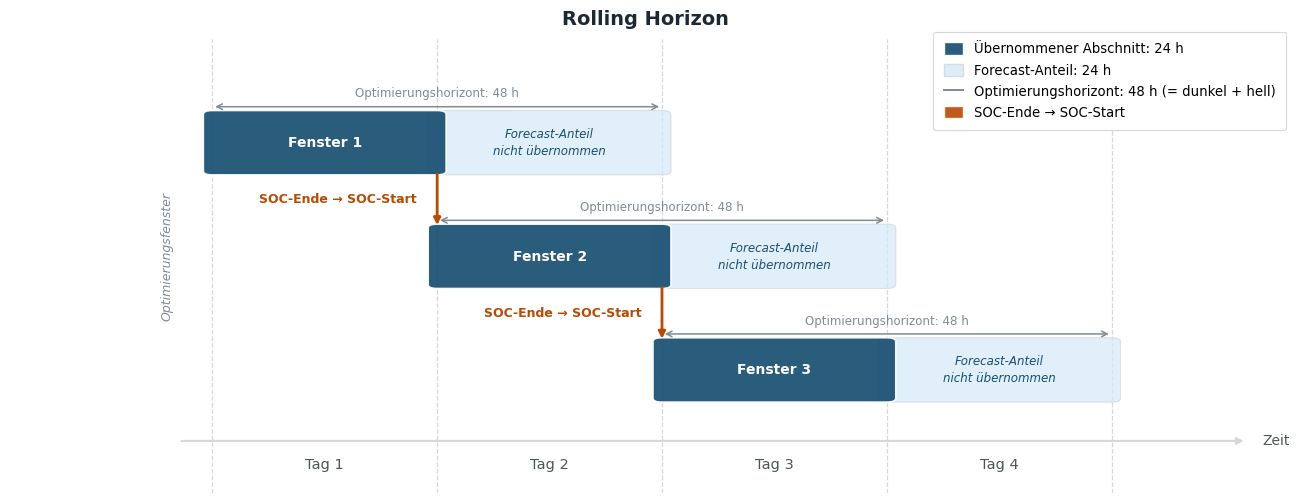

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D

C_COMMIT   = "#1A4F72"   
C_FORECAST = "#D6EAF8"   
C_SOC      = "#BA4A00"   
C_BRACKET  = "#808B96"   
C_GRID     = "#D5D8DC"   
C_LABEL    = "#4D5656"   
C_TITLE    = "#1C2833"   

fig, ax = plt.subplots(figsize=(13, 5.0))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.set_xlim(-0.9, 4.75)
ax.set_ylim(-0.95, 3.85)
ax.axis("off")

def filled_rect(x, y, w, h, color, alpha=1.0, edge="white", lw=1.2):
    ax.add_patch(FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.04",
        facecolor=color, edgecolor=edge, linewidth=lw, alpha=alpha, zorder=3,
    ))

ax.text(-0.20, 1.55, "Optimierungsfenster",
        ha="center", va="center", rotation=90,
        fontsize=9, color=C_BRACKET, fontstyle="italic")

for x in range(5):
    ax.axvline(x, color=C_GRID, linewidth=0.9, linestyle="--", zorder=1)

for i, label in enumerate(["Tag 1", "Tag 2", "Tag 3", "Tag 4"]):
    ax.text(i + 0.5, -0.65, label, ha="center", va="center",
            fontsize=10.5, color=C_LABEL)

ax.annotate("", xy=(4.60, -0.40), xytext=(-0.15, -0.40),
            arrowprops=dict(arrowstyle="-|>", color=C_GRID, lw=1.5))
ax.text(4.67, -0.40, "Zeit", ha="left", va="center", fontsize=10, color=C_LABEL)

windows = [(0, 2.75), (1, 1.55), (2, 0.35)]
H = 0.60

for i, (x0, yc) in enumerate(windows):
    yb = yc - H / 2
    filled_rect(x0 + 1, yb, 1, H, C_FORECAST, alpha=0.75, edge=C_GRID, lw=0.8)
    filled_rect(x0,     yb, 1, H, C_COMMIT,   alpha=0.93)

    ax.text(x0 + 0.5, yc, f"Fenster {i + 1}",
            ha="center", va="center",
            fontsize=10, color="white", fontweight="bold", zorder=5)
    ax.text(x0 + 1.5, yc, "Forecast-Anteil\nnicht übernommen",
            ha="center", va="center",
            fontsize=8.5, color="#1A4F72", fontstyle="italic",
            linespacing=1.4, zorder=5)

    by = yb + H + 0.08
    ax.annotate("", xy=(x0 + 2, by), xytext=(x0, by),
                arrowprops=dict(arrowstyle="<->", color=C_BRACKET,
                                lw=1.1, mutation_scale=10))
    ax.text(x0 + 1.0, by + 0.07, "Optimierungshorizont: 48 h",
            ha="center", va="bottom", fontsize=8.5, color=C_BRACKET)

for i in range(2):
    xp     = windows[i][0] + 1
    y_from = windows[i][1]   - H / 2
    y_to   = windows[i+1][1] + H / 2
    ax.annotate("", xy=(xp, y_to), xytext=(xp, y_from),
                arrowprops=dict(arrowstyle="-|>", color=C_SOC, lw=2.0), zorder=6)
    mid = (y_from + y_to) / 2
    ax.text(xp - 0.09, mid, "SOC-Ende → SOC-Start",
            ha="right", va="center",
            fontsize=9, color=C_SOC, fontweight="bold", zorder=6)

ph_c = mpatches.Patch(facecolor=C_COMMIT,   edgecolor="white", alpha=0.93,
                       label="Übernommener Abschnitt: 24 h")
ph_f = mpatches.Patch(facecolor=C_FORECAST, edgecolor=C_GRID,  alpha=0.85,
                       label="Forecast-Anteil: 24 h")
ln_b = Line2D([0], [0], color=C_BRACKET, lw=1.4,
               label="Optimierungshorizont: 48 h (= dunkel + hell)")
ph_s = mpatches.Patch(facecolor=C_SOC,      edgecolor="white", alpha=0.9,
                       label="SOC-Ende → SOC-Start")

leg = ax.legend(handles=[ph_c, ph_f, ln_b, ph_s],
                loc="upper right", fontsize=9.5, framealpha=1.0,
                edgecolor="#D5D8DC", bbox_to_anchor=(1.01, 1.03),
                handlelength=1.5, handleheight=1.05,
                borderpad=0.8, labelspacing=0.55)
leg.get_frame().set_linewidth(0.8)

ax.set_title("Rolling Horizon",
             fontsize=14, pad=10, color=C_TITLE, fontweight="600")

plt.tight_layout(pad=0.6)
plt.show()

In [5]:
import logging      # Logging-Modul: steuert Ausgaben von Bibliotheken (z.B. Solver, PyPSA)
import warnings     # Warning-Modul: steuert Warnhinweise von Bibliotheken

# Solver-, PyPSA- und FutureWarning-Logausgaben für die Schleife unten reduzieren
logging.getLogger("pypsa").setLevel(logging.ERROR) # zeigt von PyPSA nur noch Fehlermeldungen an, keine Warnungen/ Infos
logging.getLogger("linopy").setLevel(logging.ERROR) # zeigt von Linopy nur noch Fehlermeldungen an, keine warnungen/ Infos
warnings.filterwarnings("ignore", category=FutureWarning) # unterdrückt Warnhinweise von Bibliotheken, damit das Notebook bei vielen Schleifendurchläufen nicht überflutet wird

# Rolling-Horizon-Parameter
horizont_tage = 2             # Länge des Optimierungsfensters in Tagen
schritt_tage = 1              # Schrittweite (übernommener Abschnitt) in Tagen
snapshots_pro_tag = 96        # 15 min x 24 h = 96 Werte pro Tag

horizont_snapshots = horizont_tage * snapshots_pro_tag      # rechnet die Länge des Zeitfensters in Zeitschritten um (96 Werte pro Tag * 2 Tage = 192 Zeitschritte)
schritt_snapshots = schritt_tage * snapshots_pro_tag        # rechnet die Schrittwerte in Zeitschritte um (96 Werte pro Tag * 1 Tag = 96 Zeitschritte)

print(f"Optimierungsfenster: {horizont_tage} Tage ({horizont_snapshots} Zeitschritte)")     # gibt zur Kontrolle aus, wie lang das Zeitfenster ist
print(f"Schrittweite: {schritt_tage} Tag ({schritt_snapshots} Zeitschritte)")               # gibt zur Kontrolle aus, wie wet das fenster nach jedem Lauf verschoben wurde

Optimierungsfenster: 2 Tage (192 Zeitschritte)
Schrittweite: 1 Tag (96 Zeitschritte)


<div style="background: linear-gradient(90deg, #1e3a8a, #2563eb); padding:18px 22px; border-radius:12px; color:white; margin-bottom:18px;">
<h2 style="margin:0;">Schritt 4: PyPSA-Modell für ein Rolling-Horizon-Fenster definieren</h2>
<p style="margin:8px 0 0 0; font-size:16px;">
</p>
</div>

<div style="
    background:rgba(255,255,255,0.055);
    border:1px solid rgba(255,255,255,0.14);
    border-left:4px solid rgba(160,160,160,0.55);
    border-radius:8px;
    padding:10px 14px;
    margin:10px 0 14px 0;
    line-height:1.35;
">

<mark>PyPSA</mark> = Python for Power System Analysis → Open-Source-Framework zur Modellierung und Optimierung von Energiesystemen (z.B. Stromnetze, Kraftwerke). Wird genutzt, um zu berechnen:

- wie Anlagen optimal betrieben werden
- wann Speicher laden oder entladen
- welche Kosten entstehen
- wie Stromflüsse im System aussehen
- wie ein Energiesystem ausgebaut werden könnte

Für die mathematische Optimierung brauch PyPSA: Preise, Batteriedaten, technische Grenzem und eine Zielfunktion → Solver berechnet daraus den optimalen Speicherfahrplan

<span style="
background-color:#1e40af;
color:white;
padding:3px 8px;
border-radius:6px;
font-size:13px;
font-weight:600;
">Bestandteile</span>

- <span style="color:#3b82f6;">Network</span> = das gesamte Energiesystemmodell → Modellcontainer, in dem alle Komponenten gespeichert werden
- <span style="color:#3b82f6;">Snapshots</span> =  Zeitpunkte der Optimierung (15-Minuten-Zeitschritte) → in einem Zeitpunkt kann das Modell entscheiden: laden, entladen oder nichts tun
- <span style="color:#3b82f6;">Bus</span> = zentraler Knotenpunkt im Modell: alle Komponenten (z.B. Generatoren, Speicher, Lasten, Leistungen) werden an einen Bus angeschlossen → stellt sicher, dass Einspeisung und Verbrauch zusammenpassen 
- <span style="color:#3b82f6;">Generator</span> = modelliert den Strommarkt → über ihn kann Strom zum Day-Ahead-Preis gekauft/ verkauft werden.
- <span style="color:#3b82f6;">StorageUnit</span> = BESS
- <span style="color:#3b82f6;">Zeitreihen</span> = Day-Ahead-Preise
- <span style="color:#3b82f6;">Solver</span> = löst das mathematische Optimierungsproblem → berechnet, welche Entscheidung in jedem Zeitschritt optimal ist

Im Rolling-Horizon-Verfahren wird dieses PyPSA-Modell immer wieder für neue Preisfenster aufgebaut und mit dem aktualisierten SOC weitergeführt.

</p>
</div>

In [6]:
def baue_netz_fenster(preise_fenster, soc_start):       # Funktion
    n = pypsa.Network()
    n.set_snapshots(preise_fenster.index)               # setzt die Zeitpunkte des Preisfensters als Optimierungszeitpunkte
    n.snapshot_weightings.loc[:, :] = 0.25              # 15 min pro Zeitschritt 

    n.add("Bus", "Knotenpunkt")                         # Generator und StorageUnit werden angeschlossen

    n.add(
        "Generator",
        "Markt",
        bus="Knotenpunkt",
        p_nom=100,                  # sehr hohe Nennleistung, damit der Markt nie limitiert wird
        p_min_pu=-1,                # sehr niedrige min. Leistung ``-``
        p_max_pu=1,                 # sehr hohe max. Leistung ``-``
        marginal_cost=0,            # sehr niedrige Grenzkosten ``-``
    )
    n.generators_t.marginal_cost["Markt"] = preise_fenster["price"].values     # setzt die Day-Ahead-Preise als zeitabhängige Kosten/ Erlöse für den Generator

    n.add(
        "StorageUnit",
        "BESS",
        bus="Knotenpunkt",
        p_nom=p_entlade_mw,
        p_min_pu=-(p_lade_mw / p_entlade_mw),   
        max_hours=kapazität_mwh / p_entlade_mw,     # Speicherdauer: Kapazität / Entladeleistung
        efficiency_store=wirkungsgrad,
        efficiency_dispatch=wirkungsgrad,
        state_of_charge_initial=soc_start,
        cyclic_state_of_charge=False,               # SOC muss am Fensterende nicht automatisch dem Start-SOC entsprechen
    )
    return n                                        # gibt das fertige PyPSA-Netzwerk zurück

<div style="background: linear-gradient(90deg, #1e3a8a, #2563eb); padding:18px 22px; border-radius:12px; color:white; margin-bottom:18px;">
<h2 style="margin:0;">Schritt 5: Definition der KPIs</h2>
<p style="margin:8px 0 0 0; font-size:16px;">
</p>
</div>

In diesem Schritt werden Kennzahlen zur Bewertung der Optimierung definiert (Key Performance Indicators). Aus dem später erzeugten Jahresergebnis werden diese berechnet. Damit kann bewertet werden:

- <span style="color:#3b82f6;">Wirtschaftlichkeit</span>: Wie hoch ist der Nettoerlös aus dem Speicherbetrieb?
- <span style="color:#3b82f6;">Speichernutzung</span>: Wie stark wurde die Batterie über das Jahr genutzt?
- <span style="color:#3b82f6;">Arbitrage-Erfolg</span>: Wurde tatsächlich zu günstig geladen und teurer entladen?

$\displaystyle \text{Nettoerlös} = \sum_t \text{Energie}_t \cdot \text{Preis}_t$

$\displaystyle \text{Volllastzyklen} = \frac{\text{entladene Energie}}{\text{Speicherkapazität}}$

$\displaystyle \text{Spread} = \text{mittlerer Entladepreis} - \text{mittlerer Ladepreis}$

In [7]:
def berechne_kennzahlen(ergebnis_df, kapazität_mwh, dt_h=0.25):                        # Funktion
    energie_mwh = ergebnis_df["bess_leistung_mw"] * dt_h                               # Umrechnung von Leistung in Energie

    nettoerlös = (energie_mwh * ergebnis_df["preis_eur_mwh"]).sum()

    # markiert alle Zeitpunkte, an denen die Batterie lädt/ entlädt
    lade_maske = energie_mwh < 0        
    entlade_maske = energie_mwh > 0     
    
    # summiert die geladen/ entladene Energie
    geladene_energie = -energie_mwh[lade_maske].sum()         # "-" damit geladene Energie positiv wird
    entladene_energie = energie_mwh[entlade_maske].sum()      

    volllastzyklen = entladene_energie / kapazität_mwh

    # Berechnung der mittleren Lade- und Entladepreise
    mittlerer_ladepreis = (
        ergebnis_df.loc[lade_maske, "preis_eur_mwh"] * -energie_mwh[lade_maske]     # gewichtet die Ladepreise mit der jeweils geladenen Energiemenge
    ).sum() / geladene_energie      # teilt die gewichtete Preissumme durch die gesamte geladene Energie

    mittlerer_entladepreis = (
        ergebnis_df.loc[entlade_maske, "preis_eur_mwh"] * energie_mwh[entlade_maske]
    ).sum() / entladene_energie

    spread = mittlerer_entladepreis - mittlerer_ladepreis

    return pd.Series({                        # gibt alle berechneten Kennzahlen als übersichtliche Pandas-Series zurück
        "Nettoerlös [€]": nettoerlös,
        "Geladene Energie [MWh]": geladene_energie,
        "Entladene Energie [MWh]": entladene_energie,
        "Volllastzyklen": volllastzyklen,
        "Mittlerer Ladepreis [€/MWh]": mittlerer_ladepreis,
        "Mittlerer Entladepreis [€/MWh]": mittlerer_entladepreis,
        "Durchschnittlicher Spread [€/MWh]": spread,
    })

<div style="background: linear-gradient(90deg, #1e3a8a, #2563eb); padding:18px 22px; border-radius:12px; color:white; margin-bottom:18px;">
<h2 style="margin:0;">Schritt 6: Jahressimulation mit Rolling-Horizon-Optimierung</h2>
<p style="margin:8px 0 0 0; font-size:16px;">
</p>
</div>

Hier wird die zuvor definierte Rolling-Horizon-Logik auf den gesamten Datensatz angewendet. Der Datensatz enthält <span style="color:#3b82f6;">35.040 Werte</span> (= 365 Tage × 24 Stunden × 4 Viertelstunden)

<span style="
background-color:#1e40af;
color:white;
padding:3px 8px;
border-radius:6px;
font-size:13px;
font-weight:600;
">Vorgehen</span>

- Für jedes Rolling-Horizon-Fenster wird ein eigenes PyPSA-Modell erstellt
- Der Solver optimiert jeweils ein Zeitfenster von <span style="color:#3b82f6;">48 h</span>
- Übernommen wird davon nur der erste Abschnitt von <span style="color:#3b82f6;">24 h</span>
- Danach wird das Fenster um einen Tag weitergeschoben
- Der SOC am Ende des übernommenen Abschnitts wird als Start-SOC für das nächste Fenster verwendet

<span style="
background-color:#1e40af;
color:white;
padding:3px 8px;
border-radius:6px;
font-size:13px;
font-weight:600;
">Ergebnis</span>

- Die einzelnen Tagesergebnisse werden gesammelt → <span style="color:#3b82f6;">Jahresergebnis</span>
- Dieses enthält für jeden übernommenen 15-Minuten-Zeitschritt:
  - Day-Ahead-Preis
  - optimierte Lade- oder Entladeleistung der Batterie
  - SOC

**Achtung**
- Für die ersten 364 Tage ist das Fenster wie gewohnt 48h lang.
- Für den **letzten Tag** reicht der Datensatz nicht mehr für ein volles 48h-Fenster
    → Fenster wird auf den verbleibenden Tag verkürzt, 
    → **End-SOC-Bedingung** wird gesetzt



<div style="
background-color:#111827;
border:1px solid #334155;
border-left:5px solid #3b82f6;
border-radius:12px;
padding:18px 22px;
margin:18px 0;
color:#e5e7eb;
">

<div style="font-size:18px; font-weight:700; color:#ffffff; margin-bottom:8px;">

</div>

Beispiel

</div>

In [8]:
import contextlib       # wird genutzt, um Ausgaben des Solvers gezielt zu unterdrücken
import io               # Erstellt einen leeren Ausgabepuffer, in den Solver-Ausgaben umgeleitet werden können

anzahl_tage_jahr = len(preise) // snapshots_pro_tag                                         # berechnet, wie viele vollständige Tage im Datensatz enthalten sind
print(f"Simulationszeitraum: {anzahl_tage_jahr} Tage ({len(preise)} Zeitschritte)")         # gibt Dauer und Anzahl der Zeitschritte aus

soc_aktuell_jahr = soc_start_mwh        # setzt den Start-Ladezustand der Batterie für die Jahressimulation
jahres_teilergebnisse = []              # Liste, in der die Tagesergebnisse der Zeitfenster gesammelt werden

for tag_index in range(anzahl_tage_jahr):                           # Schleife über alle Tage im Jahr
    start_pos = tag_index * snapshots_pro_tag                       # bestimmt die Startposition des aktuellen Tages im Datensatz
    ende_pos = min(start_pos + horizont_snapshots, len(preise))     # bestimmt das Ende des 48h-Fensters, aber max. bis zum Ende des Datensatzes
    fenster_index = preise.index[start_pos:ende_pos]                # erstellt den Zeitindex für das aktuelle Optimierungsfenster
    preise_fenster = preise.loc[fenster_index]                      # schneidet die Day-Ahead-Preise für dieses Fenster aus dem Datensatz aus

    n_fenster = baue_netz_fenster(preise_fenster, soc_start=soc_aktuell_jahr)   # baut das PyPSA-Modell für das aktuelle Fenster mit dem aktuellen Start-SOC

    # Letztes Fenster ist ggf. kürzer als die Schrittweite (Ende des Datensatzes)
    commit_länge = min(schritt_snapshots, len(fenster_index))       # legt fest, wie viele Zeitschritte aus dem Fenster übernommen werden
    commit_index = fenster_index[:commit_länge]                     # erstellt den Index für den Abschnitt, der tatsächlich ins Jahresergebnis übernommen wird

    m = n_fenster.optimize.create_model()                           # erstellt das mathematische Optimierungsmodell für das aktuelle PyPSA-Netzwerk
    if tag_index == anzahl_tage_jahr - 1:                           # prüft, ob das aktuelle Fenster das letzte Fenster der Jahressimulation ist
        soc_var = m.variables["StorageUnit-state_of_charge"]                                        # greift auf die SOC-Variable im Optimierungsmodell zu
        m.add_constraints(soc_var.loc[commit_index[-1], "BESS"] == soc_ende_mwh, name="End-SOC")    # erzwingt, dass die Batterie am Ende den vorgegebenen End-SOC erreicht

    with contextlib.redirect_stdout(io.StringIO()):                                                 # leitet Solver-Ausgaben in einen leeren Puffer um, damit das Notebook übersichtlich bleibt
        n_fenster.optimize.solve_model(solver_name="highs", solver_options={"output_flag": False})  # löst das Optimierungsproblem mit dem HiGHS-Solver

    teilergebnis = pd.DataFrame({                                                                   # erstellt eine Ergebnistabelle für den übernommenen Abschnitt dieses Fensters
        "preis_eur_mwh": preise_fenster.loc[commit_index, "price"],                                 # speichert die Day-Ahead-Preise des übernommenen Abschnitts
        "bess_leistung_mw": n_fenster.storage_units_t.p.loc[commit_index, "BESS"],                  # speichert die optimierte Lade-/Entladeleistung der Batterie
        "soc_mwh": n_fenster.storage_units_t.state_of_charge.loc[commit_index, "BESS"],             # speichert den Ladezustand der Batterie     
    })
    jahres_teilergebnisse.append(teilergebnis)                                                      # fügt das Tagesergebnis zur Liste aller Jahres-Teilergebnisse hinzu


    soc_aktuell_jahr = n_fenster.storage_units_t.state_of_charge.loc[commit_index[-1], "BESS"]      # übergibt den End-SOC des übernommenen Abschnitts als Start-SOC für das nächste Fenster

    if (tag_index + 1) % 30 == 0 or tag_index == anzahl_tage_jahr - 1:                              # gibt nur alle 30 Tage und am letzten Tageinen Fortschritt aus
        print(f"Tag {tag_index + 1}/{anzahl_tage_jahr}: SOC = {soc_aktuell_jahr:.3f} MWh")          # zeigt aktuellen Fortschritt und Ladezustand an

jahresergebnis = pd.concat(jahres_teilergebnisse)                                                   # fügt alle übernommenen Tagesabschnitte zu einer großen Jahrestabelle zusammen

print() 
print(f"Anzahl Zeitschritte im Jahresergebnis: {len(jahresergebnis)}")                              # prüft, ob das Jahresergebnis alle 35.040 Zeitschritte enthält

Simulationszeitraum: 365 Tage (35040 Zeitschritte)
Tag 30/365: SOC = 0.225 MWh
Tag 60/365: SOC = 0.225 MWh
Tag 90/365: SOC = 0.450 MWh
Tag 120/365: SOC = 0.225 MWh
Tag 150/365: SOC = 0.225 MWh
Tag 180/365: SOC = 0.225 MWh
Tag 210/365: SOC = -0.000 MWh
Tag 240/365: SOC = 0.425 MWh
Tag 270/365: SOC = 0.278 MWh
Tag 300/365: SOC = -0.000 MWh
Tag 330/365: SOC = -0.000 MWh
Tag 360/365: SOC = 1.603 MWh
Tag 365/365: SOC = 1.000 MWh

Anzahl Zeitschritte im Jahresergebnis: 35040


<div style="background: linear-gradient(90deg, #1e3a8a, #2563eb); padding:10px 16px; border-radius:8px; color:white; margin-bottom:12px;">
  <h2 style="margin:0; font-size:24px; font-weight:600;">Auswertung der Jahresergebnisse</h2>
</div>

Die zuvor definierte Funktion zur <span style="color:#3b82f6;">Berechnung der KPIs/ Kennzahlen</span> wird auf das Jahresergebnis der Rolling-Horizon-Simulation angewendet → KPIs des Batteriespeicherbetriebs über das gesamte Jahr berechnet.

Zusätzlich werden die <span style="color:#3b82f6;">Volllastzyklen pro Tag</span> berechnet, um die Nutzung des Speichers besser einordnen zu können.

In [9]:
kennzahlen_jahr = berechne_kennzahlen(jahresergebnis, kapazität_mwh)                                    # berechnet die KPIs für das gesamte Jahr basierend auf dem Jahresergebnis
kennzahlen_jahr["Volllastzyklen pro Tag"] = kennzahlen_jahr["Volllastzyklen"] / anzahl_tage_jahr        # berechnet die durchschnittlichen Vollzyklen pro Tag

pd.DataFrame({f"Jahr ({anzahl_tage_jahr} Tage)": kennzahlen_jahr})                                      # wandelt die KPIs in eine übersichtliche Tabelle mit einer Jahresspalte um

,Jahr (365 Tage)
Nettoerlös [€],127489.314
Geladene Energie [MWh],2445.209
Entladene Energie [MWh],1972.073
Volllastzyklen,986.037
Mittlerer Ladepreis [€/MWh],47.979
Mittlerer Entladepreis [€/MWh],124.137
Durchschnittlicher Spread [€/MWh],76.158
Volllastzyklen pro Tag,2.701


<div style="background: linear-gradient(90deg, #1e3a8a, #2563eb); padding:10px 16px; border-radius:8px; color:white; margin-bottom:12px;">
  <h2 style="margin:0; font-size:24px; font-weight:600;">Visualisierung der Jahresergebnisse</h2>
</div>

In diesem Schritt werden die Ergebnisse der Rolling-Horizon-Simulation über das Jahr grafisch dargestellt.

<span style="
background-color:#1e40af;
color:white;
padding:3px 8px;
border-radius:6px;
font-size:13px;
font-weight:600;
">Graph 1</span>: durchschnittlicher SOC (Tagesmitte mit 7-Tage-Glättung)

<span style="
background-color:#1e40af;
color:white;
padding:3px 8px;
border-radius:6px;
font-size:13px;
font-weight:600;
">Graph 2</span>: monatlicher Nettoerlös (kumuliert)

Durch die Aggregation auf Tages- und Monatswerte werden die 15-Minuten-Ergebnisse übersichtlicher dargestellt. So lassen sich saisonale Muster, Unterschiede in der Preisvolatilität und die wirtschaftliche Performance der Batterie über das Jahr besser erkennen.

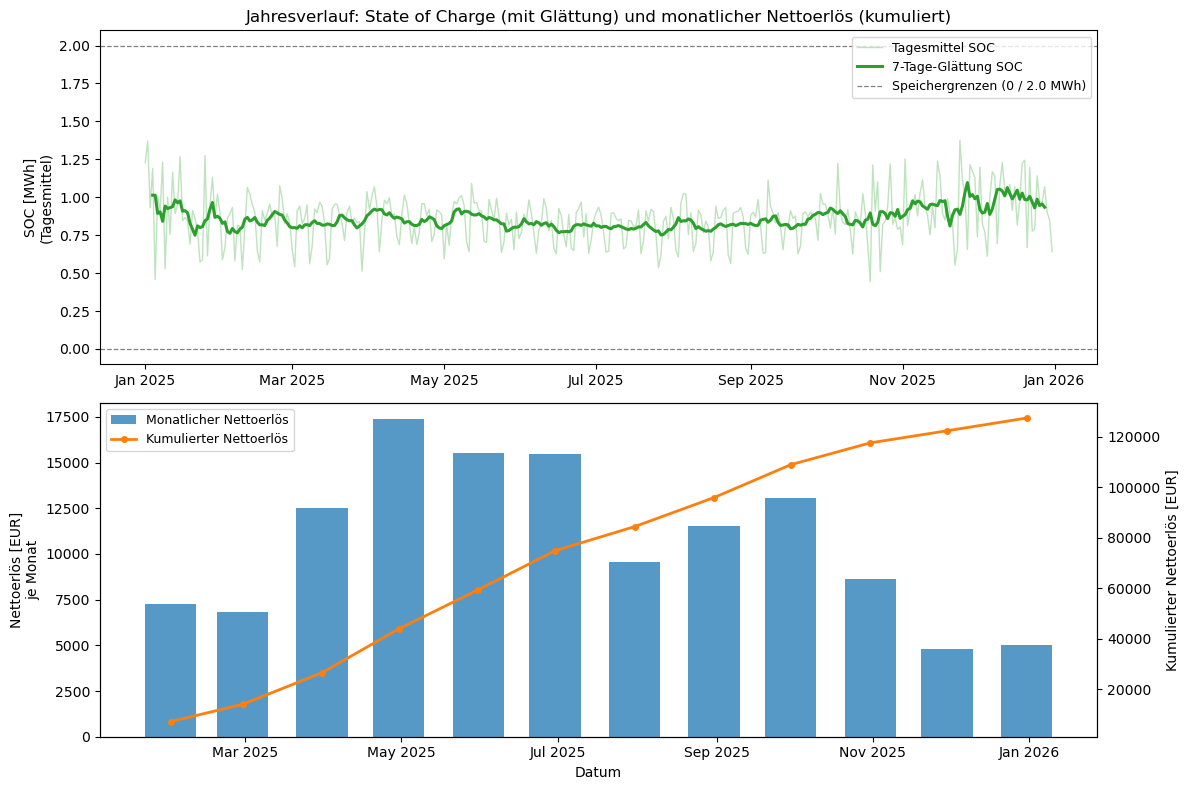

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Nur Kalenderjahr 2025 (4 Restwerte aus 2024-12-31 werden ausgeblendet)
plot_df = jahresergebnis.loc["2025-01-01":"2025-12-31"]

# SOC: Tagesmittel und 7-Tage-Glättung
soc_taeglich   = plot_df["soc_mwh"].resample("D").mean()
soc_geglaettet = soc_taeglich.rolling(window=7, center=True).mean()

# Nettoerlös: monatlich und kumuliert
erloes_je_schritt = plot_df["bess_leistung_mw"] * plot_df["preis_eur_mwh"] * 0.25
erloes_monatlich  = erloes_je_schritt.resample("ME").sum()
erloes_kumuliert  = erloes_monatlich.cumsum()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# --- Oben: SOC-Verlauf mit 7-Tage-Glättung ---
axes[0].plot(soc_taeglich.index,   soc_taeglich,   color="tab:green", alpha=0.3, linewidth=1,   label="Tagesmittel SOC")
axes[0].plot(soc_geglaettet.index, soc_geglaettet, color="tab:green", linewidth=2.2,             label="7-Tage-Glättung SOC")
axes[0].axhline(0,              color="grey", linewidth=0.9, linestyle="--", label=f"Speichergrenzen (0 / {kapazität_mwh} MWh)")
axes[0].axhline(kapazität_mwh,  color="grey", linewidth=0.9, linestyle="--")
axes[0].set_ylabel("SOC [MWh]\n(Tagesmittel)")
axes[0].set_title("Jahresverlauf: State of Charge (mit Glättung) und monatlicher Nettoerlös (kumuliert)")
axes[0].legend(loc="upper right", fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# --- Unten: monatlicher Nettoerlös (Balken) + kumulierter Nettoerlös (zweite y-Achse) ---
axes[1].bar(erloes_monatlich.index, erloes_monatlich, width=20, color="tab:blue", alpha=0.75, label="Monatlicher Nettoerlös")
axes[1].set_ylabel("Nettoerlös [EUR]\nje Monat")
axes[1].set_xlabel("Datum")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

ax2 = axes[1].twinx()
ax2.plot(erloes_monatlich.index, erloes_kumuliert, color="tab:orange", linewidth=2.0, marker="o", markersize=4, label="Kumulierter Nettoerlös")
ax2.set_ylabel("Kumulierter Nettoerlös [EUR]")

# Legenden beider Achsen zusammenführen
h1, l1 = axes[1].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
axes[1].legend(h1 + h2, l1 + l2, loc="upper left", fontsize=9)

fig.tight_layout()
plt.show()

## Nächste Schritte

- Vergleich Rolling-Horizon-Ergebnis vs. "Perfect Foresight" (Optimierung des gesamten
  Jahres in einem Lauf) – zeigt den Effekt des begrenzten Vorhersagehorizonts
- Sensitivitätsanalyse: andere Fenstergrößen/Schrittweiten (z.B. 72h-Fenster, 12h-Schritt)
- Optional: Multi-Market-Optimierung, Netzrestriktionen, CO2-Preis-Szenarien
  (siehe Projektbeschreibung)